In [1]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from LBFGS import *

In [2]:
class CubeWithNonUniformLoading(keras.Model):
    def __init__(self, network_u, network_v, network_w, train_op, num_epoch, data_type):
        super().__init__()
        self.network_u = network_u
        self.network_v = network_v
        self.network_w = network_w
        self.optimizer = train_op  # store optimizer here
        self.num_epoch = num_epoch
        self.data_type = data_type
        self.print_epoch = 100
        self.network_u.build((None, 3))
        self.network_v.build((None, 3))
        self.network_w.build((None, 3))

    @tf.function
    def u(self, X):
        x = X[:, 0:1]
        X1 = self.network_u(X)
        return X1 * x
    
    @tf.function
    def v(self, X):
        y = X[:, 1:2]
        X1 = self.network_v(X)
        return X1 * y
    
    @tf.function
    def w(self, X):
        z = X[:, 2:3]
        X1 = self.network_w(X)
        return X1 * z
    
    @tf.function
    def call(self, X):
        uVal = self.u(X)
        vVal = self.v(X)
        wVal = self.w(X)
        disp = tf.concat([uVal, vVal, wVal], axis=1)
        return disp
    
    @tf.function
    def strains(self, X):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(X)
            U = self.u(X)
            V = self.v(X)
            W = self.w(X)
        
        du = tape.gradient(U, X)
        dv = tape.gradient(V, X)
        dw = tape.gradient(W, X)

        du_dx = du[:, 0:1]
        du_dy = du[:, 1:2]
        du_dz = du[:, 2:3]
        dv_dx = dv[:, 0:1]
        dv_dy = dv[:, 1:2]
        dv_dz = dv[:, 2:3]
        dw_dx = dw[:, 0:1]
        dw_dy = dw[:, 1:2]
        dw_dz = dw[:, 2:3]

        del tape

        epsilon_xx = du_dx
        epsilon_yy = dv_dy
        epsilon_zz = dw_dz
        epsilon_xy = du_dy + dv_dx
        epsilon_yz = dv_dz + dw_dy
        epsilon_xz = du_dz + dw_dx

        return epsilon_xx, epsilon_yy, epsilon_zz, epsilon_xy, epsilon_yz, epsilon_xz
    
    @tf.function
    def stress(self, X):
        E = 1
        nu = 0.25
        epsilon_xx, epsilon_yy, epsilon_zz, epsilon_xy, epsilon_yz, epsilon_xz = self.strains(X)
        factor = E / ((1 + nu) * (1 - 2 * nu))
        sigma_xx = factor * ((1 - nu) * epsilon_xx +     nu * epsilon_yy +     nu * epsilon_zz)
        sigma_yy = factor * (    nu * epsilon_xx + (1 - nu) * epsilon_yy +     nu * epsilon_zz)
        sigma_zz = factor * (    nu * epsilon_xx +     nu * epsilon_yy + (1 - nu) * epsilon_zz)

        sigma_xy = E / (2 * (1 + nu)) * epsilon_xy
        sigma_yz = E / (2 * (1 + nu)) * epsilon_yz
        sigma_xz = E / (2 * (1 + nu)) * epsilon_xz

        return sigma_xx, sigma_yy, sigma_zz, sigma_xy, sigma_yz, sigma_xz
    

    @tf.function
    def equilibrium(self, X):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(X)
            sigma_xx, sigma_yy, sigma_zz, sigma_xy, sigma_yz, sigma_xz = self.stress(X)

        dsigma_xx = tape.gradient(sigma_xx, X)
        dsigma_yy = tape.gradient(sigma_yy, X)
        dsigma_zz = tape.gradient(sigma_zz, X)
        dsigma_xy = tape.gradient(sigma_xy, X)
        dsigma_yz = tape.gradient(sigma_yz, X)
        dsigma_xz = tape.gradient(sigma_xz, X)

        # Extract the specific partial derivatives:
        dsigma_xx_dx = dsigma_xx[:, 0:1]  #
        dsigma_xy_dy = dsigma_xy[:, 1:2]  
        dsigma_xz_dz = dsigma_xz[:, 2:3]  

        dsigma_yy_dy = dsigma_yy[:, 1:2]  
        dsigma_xy_dx = dsigma_xy[:, 0:1]  
        dsigma_yz_dz = dsigma_yz[:, 2:3]  

        dsigma_zz_dz = dsigma_zz[:, 2:3]  
        dsigma_yz_dy = dsigma_yz[:, 1:2]  
        dsigma_xz_dx = dsigma_xz[:, 0:1]

        del tape

        ge_x = dsigma_xx_dx + dsigma_xy_dy + dsigma_xz_dz
        ge_y = dsigma_yy_dy + dsigma_xy_dx + dsigma_yz_dz
        ge_z = dsigma_zz_dz + dsigma_yz_dy + dsigma_xz_dx

        return ge_x, ge_y, ge_z
    
    #@tf.function
    def loss_all(self, X_dom, Y_dom):
        ge_x, ge_y, ge_z = self.equilibrium(X_dom)
        loss_eq = tf.reduce_mean(tf.square(ge_x)) + tf.reduce_mean(tf.square(ge_y)) + tf.reduce_mean(tf.square(ge_z))

        Lx = 1.0
        Ly = 1.0
        Lz = 1.0
        ns_b = 21
        x_vals = np.linspace(0, Lx, ns_b).astype(np.float32)
        y_vals = np.linspace(0, Ly, ns_b).astype(np.float32)
        z_vals = np.linspace(0, Lz, ns_b).astype(np.float32)

        # Top face (z = 1)

        xx_t, yy_t = np.meshgrid(x_vals, y_vals)
        zz_t = np.ones_like(xx_t)

        X_top = tf.convert_to_tensor(np.stack([xx_t, yy_t, zz_t], axis=-1).reshape(-1, 3), dtype=tf.float32)
        sigma_xx_t, sigma_yy_t, sigma_zz_t, sigma_xy_t, sigma_yz_t, sigma_xz_t = self.stress(X_top)

        traction = tf.cos(math.pi * xx_t/2) * tf.cos(math.pi * yy_t/2)
        traction_r = tf.reshape(traction, [-1, 1])  # Shape: (121, 1)


        loss_boundary_D1 = tf.reduce_mean(tf.square(sigma_yz_t - 0)) + \
                        tf.reduce_mean(tf.square(sigma_xz_t - 0)) + tf.reduce_mean(tf.square(sigma_zz_t - traction_r))
        

        # Bottom face (z = 0)

        xx_b, yy_b = np.meshgrid(x_vals, y_vals)
        zz_b = np.zeros_like(xx_b)

        X_bottom = tf.convert_to_tensor(np.stack([xx_b, yy_b, zz_b], axis=-1).reshape(-1, 3), dtype=tf.float32)
        sigma_xx_b, sigma_yy_b, sigma_zz_b, sigma_xy_b, sigma_yz_b, sigma_xz_b = self.stress(X_bottom)

        loss_boundary_D2 = tf.reduce_mean(tf.square(sigma_xz_b - 0)) + tf.reduce_mean(tf.square(sigma_yz_b - 0))

        # Front face (y = 1)

        xx_f, zz_f = np.meshgrid(x_vals, z_vals)
        yy_f = np.ones_like(xx_f)

        X_front = tf.convert_to_tensor(np.stack([xx_f, yy_f, zz_f], axis=-1).reshape(-1, 3), dtype=tf.float32)
        sigma_xx_f, sigma_yy_f, sigma_zz_f, sigma_xy_f, sigma_yz_f, sigma_xz_f = self.stress(X_front)

        loss_boundary_D3 = tf.reduce_mean(tf.square(sigma_xy_f - 0)) + tf.reduce_mean(tf.square(sigma_yz_f - 0)) + tf.reduce_mean(tf.square(sigma_yy_f - 0))

        # Back face (y = 0)

        xx_ba, zz_ba = np.meshgrid(x_vals, z_vals)
        yy_ba = np.zeros_like(xx_ba)

        X_back = tf.convert_to_tensor(np.stack([xx_ba, yy_ba, zz_ba], axis=-1).reshape(-1, 3), dtype=tf.float32)
        sigma_xx_ba, sigma_yy_ba, sigma_zz_ba, sigma_xy_ba, sigma_yz_ba, sigma_xz_ba = self.stress(X_back)

        loss_boundary_D4 = tf.reduce_mean(tf.square(sigma_xy_ba - 0)) + tf.reduce_mean(tf.square(sigma_yz_ba - 0))

        # Right face (x = 1)

        yy_r, zz_r = np.meshgrid(y_vals, z_vals)
        xx_r = np.ones_like(yy_r)

        X_right = tf.convert_to_tensor(np.stack([xx_r, yy_r, zz_r], axis=-1).reshape(-1, 3), dtype=tf.float32)
        sigma_xx_r, sigma_yy_r, sigma_zz_r, sigma_xy_r, sigma_yz_r, sigma_xz_r = self.stress(X_right)

        loss_boundary_D5 = tf.reduce_mean(tf.square(sigma_xx_r - 0)) + tf.reduce_mean(tf.square(sigma_xy_r - 0)) + tf.reduce_mean(tf.square(sigma_xz_r - 0))

        # Left face (x = 0)

        yy_l, zz_l = np.meshgrid(y_vals, z_vals)
        xx_l = np.zeros_like(yy_r)

        X_left = tf.convert_to_tensor(np.stack([xx_l, yy_l, zz_l], axis=-1).reshape(-1, 3), dtype=tf.float32)
        sigma_xx_l, sigma_yy_l, sigma_zz_l, sigma_xy_l, sigma_yz_l, sigma_xz_l = self.stress(X_left)

        loss_boundary_D6 = tf.reduce_mean(tf.square(sigma_xy_l - 0)) + tf.reduce_mean(tf.square(sigma_xz_l - 0))

        loss_boundary =  loss_boundary_D1 + loss_boundary_D2 + loss_boundary_D3 + loss_boundary_D4 +\
                             loss_boundary_D5 + loss_boundary_D6
        
        return loss_eq, loss_boundary
    
    #@tf.function
    def loss_grad(self, X_dom, Y_dom):
        with tf.GradientTape() as tape:
            #tape.watch(self.trainable_variables)
            loss_eq, loss_boundary = self.loss_all(X_dom, Y_dom)
            losses = loss_eq + loss_boundary
        grad = tape.gradient(losses, self.trainable_variables)
        return loss_eq, loss_boundary, losses, grad
    
    #@tf.function
    def train(self, X_dom, Y_dom):
        for epoch in range(self.num_epoch):
            with tf.GradientTape() as tape:
                loss_val1, loss_val2 = self.loss_all(X_dom, Y_dom)
                loss_val = loss_val1 + loss_val2
                grads = tape.gradient(loss_val, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

            if (epoch + 1) % self.print_epoch == 0:
                print(f"  PDE Loss: {loss_val1.numpy():.4e}, Boundary Loss: {loss_val2.numpy():.4e}")
                print("Epoch:", epoch + 1, "Loss:", loss_val.numpy())














In [3]:
Lx = 1.0
Ly = 1.0   
Lz = 1.0

num_points = 41
x = np.linspace(0, Lx, num_points, dtype=np.float32)
y = np.linspace(0, Lx, num_points, dtype=np.float32)
z = np.linspace(0, Lx, num_points, dtype=np.float32)
X, Y, Z = np.meshgrid(x, y, z)
points = np.stack((X.flatten(), Y.flatten(), Z.flatten()), axis=1)
x_domain = points
y_domain = np.zeros_like(x_domain)
data_type = 'float32'
X_dom_tf = tf.convert_to_tensor(x_domain, dtype=tf.float32)
Y_dom_tf = tf.convert_to_tensor(y_domain, dtype=tf.float32)
tf.keras.backend.set_floatx(data_type)

network_u = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

network_v = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

network_w = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

train_op = tf.keras.optimizers.Adam(learning_rate=0.005)
num_epoch = 1000
pred_model = CubeWithNonUniformLoading(network_u, network_v, network_w, train_op, num_epoch, data_type)
pred_model.train(X_dom_tf, Y_dom_tf)

  PDE Loss: 6.5159e-03, Boundary Loss: 5.0840e-02
Epoch: 100 Loss: 0.057355795
  PDE Loss: 7.6458e-03, Boundary Loss: 3.0316e-02
Epoch: 200 Loss: 0.037961446
  PDE Loss: 7.1188e-03, Boundary Loss: 2.2974e-02
Epoch: 300 Loss: 0.030092414
  PDE Loss: 6.1331e-03, Boundary Loss: 1.6544e-02
Epoch: 400 Loss: 0.022676777
  PDE Loss: 5.3659e-03, Boundary Loss: 1.2219e-02
Epoch: 500 Loss: 0.017585043
  PDE Loss: 4.9242e-03, Boundary Loss: 9.9404e-03
Epoch: 600 Loss: 0.014864599
  PDE Loss: 7.0560e-03, Boundary Loss: 2.0237e-02
Epoch: 700 Loss: 0.027292669
  PDE Loss: 3.7862e-03, Boundary Loss: 6.7365e-03
Epoch: 800 Loss: 0.010522699
  PDE Loss: 3.8833e-03, Boundary Loss: 1.1838e-02
Epoch: 900 Loss: 0.015720878
  PDE Loss: 3.1525e-03, Boundary Loss: 5.5224e-03
Epoch: 1000 Loss: 0.00867486


In [4]:
l_bfgs_b = Opt_lbfgsb(pred_model, X_dom_tf, Y_dom_tf)
result = l_bfgs_b.fit()

Optimizer: L-BFGS-B (Provided by Scipy package)
Initializing the framework ...
Iteration: 1 Loss = 0.008665562 
Iteration: 2 Loss = 48.564564 
Iteration: 3 Loss = 0.008665278 
Iteration: 4 Loss = 0.008664995 
Iteration: 5 Loss = 0.008661168 
Iteration: 6 Loss = 0.008654062 
Iteration: 7 Loss = 0.008636085 
Iteration: 8 Loss = 0.008603576 
Iteration: 9 Loss = 0.008545049 
Iteration: 10 Loss = 0.008535394 
Iteration: 11 Loss = 0.008483875 
Iteration: 12 Loss = 0.008360909 
Iteration: 13 Loss = 0.008257612 
Iteration: 14 Loss = 0.008210467 
Iteration: 15 Loss = 0.008169581 
Iteration: 16 Loss = 0.008110961 
Iteration: 17 Loss = 0.008017518 
Iteration: 18 Loss = 0.007910323 
Iteration: 19 Loss = 0.007834599 
Iteration: 20 Loss = 0.0077558593 
Iteration: 21 Loss = 0.0076931277 
Iteration: 22 Loss = 0.0076526315 
Iteration: 23 Loss = 0.007620927 
Iteration: 24 Loss = 0.00757684 
Iteration: 25 Loss = 0.0075017135 
Iteration: 26 Loss = 0.007424428 
Iteration: 27 Loss = 0.007327484 
Iteration: 

In [4]:
Lx = 1.0
Ly = 1.0   
Lz = 1.0

num_points = 61
x = np.linspace(0, Lx, num_points, dtype=np.float32)
y = np.linspace(0, Lx, num_points, dtype=np.float32)
z = np.linspace(0, Lx, num_points, dtype=np.float32)
X, Y, Z = np.meshgrid(x, y, z)
points = np.stack((X.flatten(), Y.flatten(), Z.flatten()), axis=1)
x_domain = points
y_domain = np.zeros_like(x_domain)
X = x_domain[:, 0:1]
Y = x_domain[:, 1:2]
Z = x_domain[:, 2:3]

predicted_sigma_xx, predicted_sigma_yy, predicted_sigma_zz, predicted_sigma_xy, predicted_sigma_yz, predicted_sigma_xz = pred_model.stress(x_domain)
predicted_displacement = pred_model(x_domain)
x_disp = predicted_displacement[:, 0:1]
y_disp = predicted_displacement[:, 1:2]
z_disp = predicted_displacement[:, 2:3]

NameError: name 'pred_model' is not defined

In [6]:
# from mpl_toolkits.mplot3d import Axes3D  # Import this for 3D plotting
# import matplotlib.pyplot as plt

# fig = plt.figure(figsize=(6, 4))
# ax = fig.add_subplot(111, projection='3d')

# # Make sure X, Y, Z, and predicted_sigma_xx are 1D arrays of the same length
# scatter = ax.scatter(
#     X.flatten(), Y.flatten(), Z.flatten(), 
#     c=x_disp.numpy().flatten(), 
#     cmap='jet', edgecolors='k', linewidths=0.005, s=50
# )

# cbar = plt.colorbar(scatter, ax=ax)  # Attach colorbar to the same axis
# cbar.set_label('U')

# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.set_title('variation of U')
# ax.view_init(elev=10, azim=-120)
# plt.show()


In [7]:
# from mpl_toolkits.mplot3d import Axes3D  # Import this for 3D plotting
# import matplotlib.pyplot as plt

# fig = plt.figure(figsize=(6, 4))
# ax = fig.add_subplot(111, projection='3d')

# # Make sure X, Y, Z, and predicted_sigma_xx are 1D arrays of the same length
# scatter = ax.scatter(
#     X.flatten(), Y.flatten(), Z.flatten(), 
#     c=y_disp.numpy().flatten(), 
#     cmap='jet', edgecolors='k', linewidths=0.005, s=50
# )

# cbar = plt.colorbar(scatter, ax=ax)  # Attach colorbar to the same axis
# cbar.set_label('U')

# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# ax.set_title('variation of U')
# ax.view_init(elev=10, azim=-120)
# plt.show()


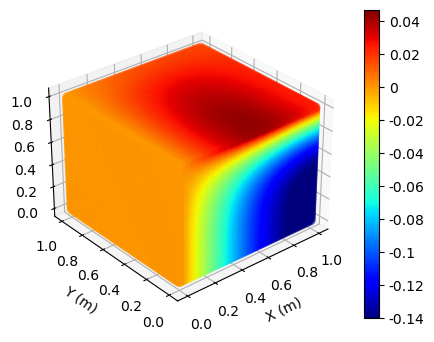

In [42]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# Explicitly set vmin and vmax to match the reference colorbar
vmin = -0.14
vmax = 0.047

# Your scatter plot call with fixed color limits
scatter = ax.scatter(
    X.flatten(), Y.flatten(), Z.flatten(),
    c=x_disp.numpy().flatten(), 
    cmap='jet', edgecolors='k', linewidths=0.005, s=50,
    vmin=vmin, vmax=vmax
)

cbar = plt.colorbar(scatter, ax=ax)
#cbar.set_label('U (m)')

# Set ticks to match the reference colorbar
tick_values = [-0.14, -0.12, -0.10, -0.08, -0.06, -0.04, -0.02, 0, 0.02, 0.04]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([str(t) for t in tick_values])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)', labelpad=10)
#ax.set_title('variation of U')
ax.view_init(elev=30, azim=-130)


plt.show()


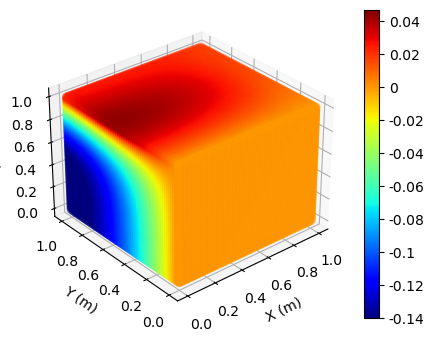

In [45]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# Explicitly set vmin and vmax to match the reference colorbar
vmin = -0.14
vmax = 0.047

# Your scatter plot call with fixed color limits
scatter = ax.scatter(
    X.flatten(), Y.flatten(), Z.flatten(),
    c=y_disp.numpy().flatten(), 
    cmap='jet', edgecolors='k', linewidths=0.005, s=50,
    vmin=vmin, vmax=vmax
)

cbar = plt.colorbar(scatter, ax=ax)
#cbar.set_label('V (m)')

# Set ticks to match the reference colorbar
tick_values = [-0.14, -0.12, -0.10, -0.08, -0.06, -0.04, -0.02, 0, 0.02, 0.04]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([str(t) for t in tick_values])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
#ax.set_title('variation of V')
ax.view_init(elev=30, azim=-130)
plt.show()


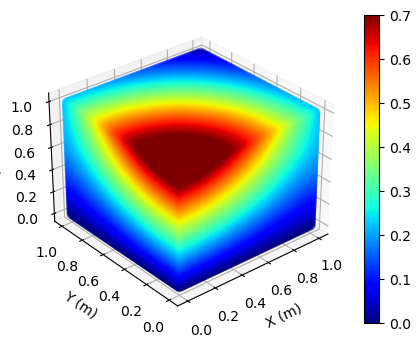

In [46]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# Explicitly set vmin and vmax to match the reference colorbar
vmin = 0.0
vmax = 0.7

# Your scatter plot call with fixed color limits
scatter = ax.scatter(
    X.flatten(), Y.flatten(), Z.flatten(),
    c=z_disp.numpy().flatten(), 
    cmap='jet', edgecolors='k', linewidths=0.005, s=50,
    vmin=vmin, vmax=vmax
)

cbar = plt.colorbar(scatter, ax=ax)
#cbar.set_label('W (m)')

# Set ticks to match the reference colorbar
tick_values = np.linspace(0, 0.7, 8)
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f'{t:.1f}' for t in tick_values])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
#ax.set_title('variation of W')
ax.view_init(elev=30, azim=-130)
plt.show()


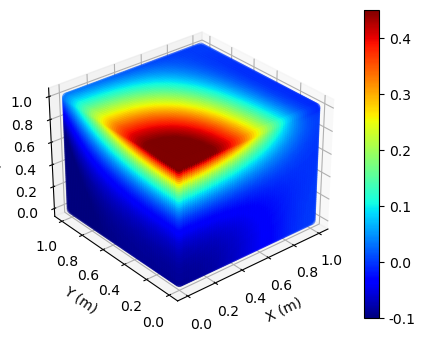

In [49]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# Explicitly set vmin and vmax to match the reference colorbar
vmin = -0.1
vmax = 0.45

# Your scatter plot call with fixed color limits
scatter = ax.scatter(
    X.flatten(), Y.flatten(), Z.flatten(),
    c=predicted_sigma_xx.numpy().flatten(), 
    cmap='jet', edgecolors='k', linewidths=0.005, s=50,
    vmin=vmin, vmax=vmax
)

cbar = plt.colorbar(scatter, ax=ax)
#cbar.set_label('Sigma_xx (Pa)')

# Set ticks to match the reference colorbar
tick_values = [-0.1, 0, 0.1, 0.2, 0.3, 0.4]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f'{t:.1f}' for t in tick_values])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
#ax.set_title('Sigma_xx')
ax.view_init(elev=30, azim=-130)
plt.show()


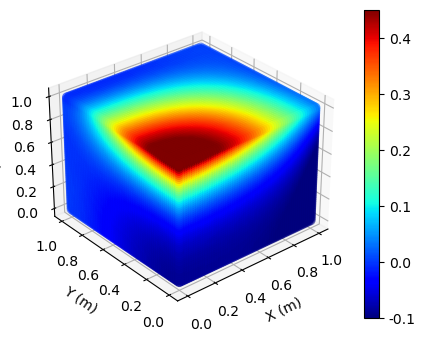

In [50]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')

# Explicitly set vmin and vmax to match the reference colorbar
vmin = -0.1
vmax = 0.45

# Your scatter plot call with fixed color limits
scatter = ax.scatter(
    X.flatten(), Y.flatten(), Z.flatten(),
    c=predicted_sigma_yy.numpy().flatten(), 
    cmap='jet', edgecolors='k', linewidths=0.005, s=50,
    vmin=vmin, vmax=vmax
)

cbar = plt.colorbar(scatter, ax=ax)
#cbar.set_label('Sigma_yy (Pa)')

# Set ticks to match the reference colorbar
tick_values = [-0.1, 0, 0.1, 0.2, 0.3, 0.4]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f'{t:.1f}' for t in tick_values])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
#ax.set_title('Sigma_yy')
ax.view_init(elev=30, azim=-130)
plt.show()


NameError: name 'X' is not defined

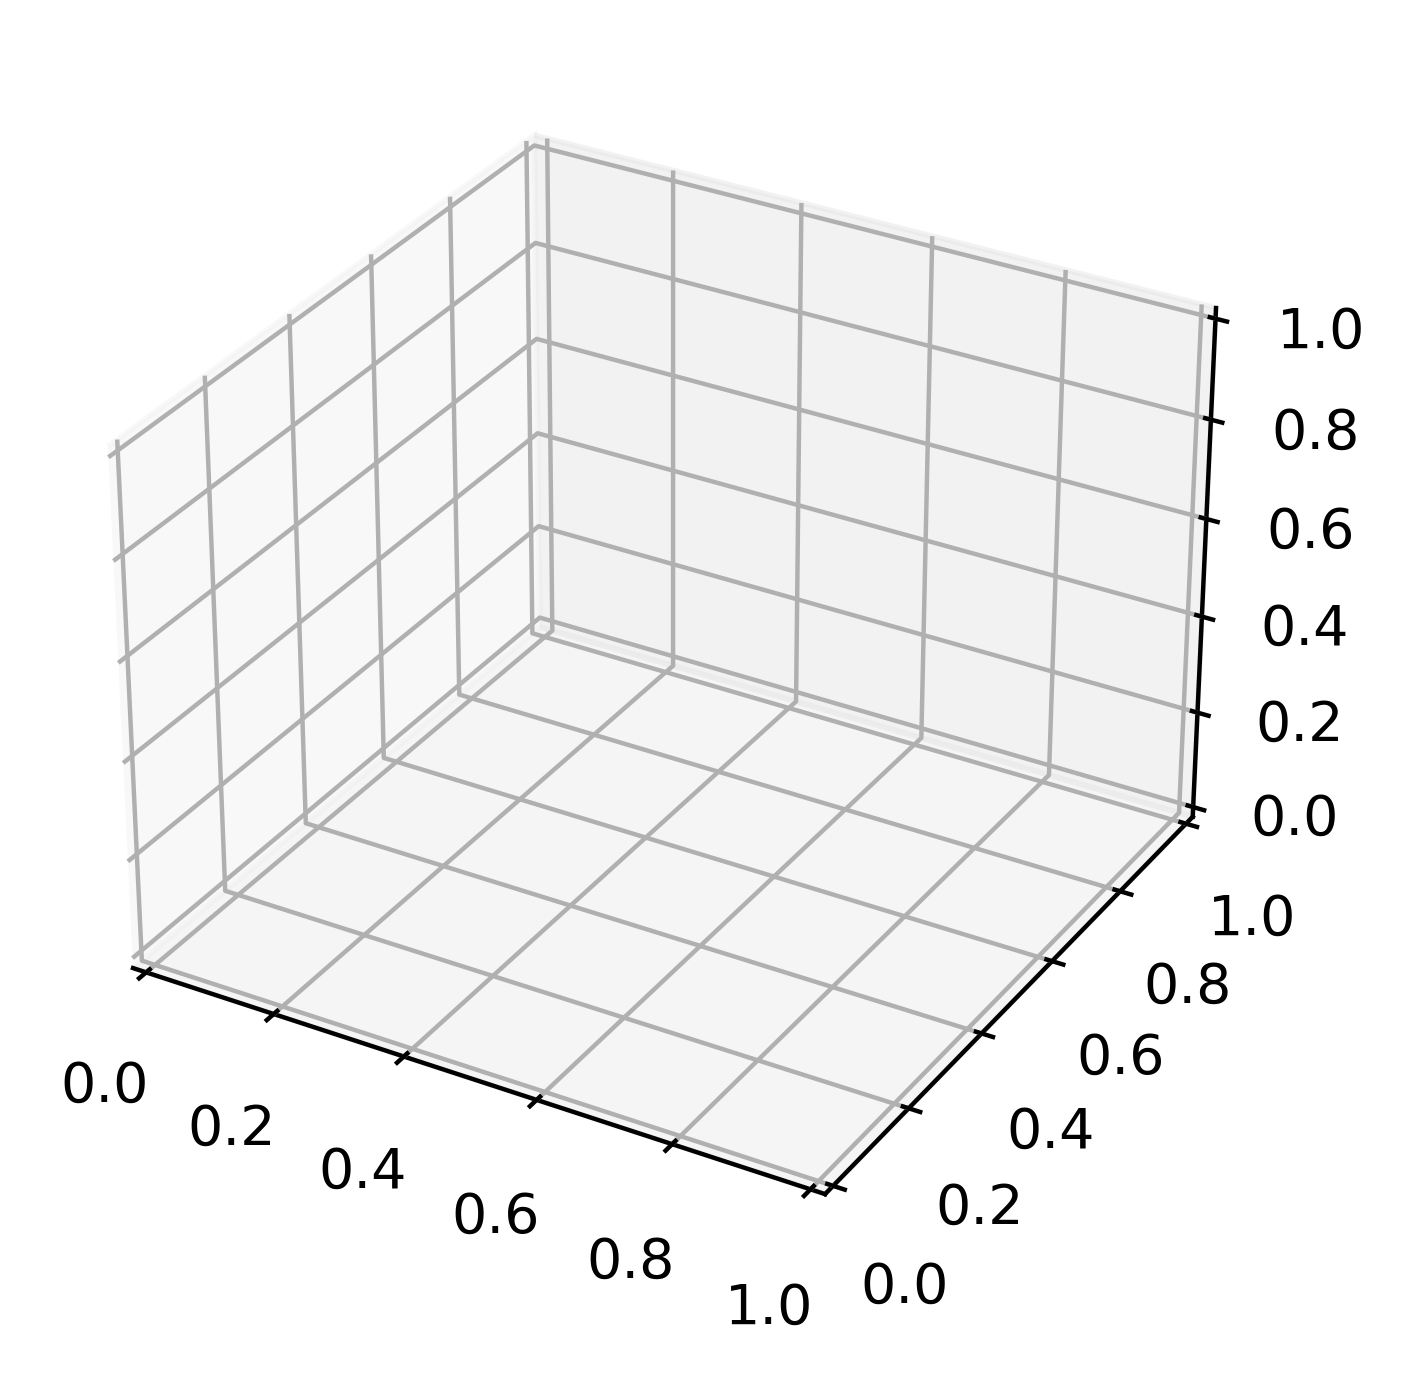

In [1]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 4), dpi=400)
ax = fig.add_subplot(111, projection='3d')

# Explicitly set vmin and vmax to match the reference colorbar
vmin = 0
vmax = 1

# Your scatter plot call with fixed color limits
scatter = ax.scatter(
    X.flatten(), Y.flatten(), Z.flatten(),
    c=predicted_sigma_zz.numpy().flatten(), 
    cmap='jet', edgecolors='k', linewidths=0.005, s=50,
    vmin=vmin, vmax=vmax
)

cbar = plt.colorbar(scatter, ax=ax)
#cbar.set_label('Sigma_zz (Pa)')

# Set ticks to match the reference colorbar
tick_values = [0, 0.2, 0.4, 0.6, 0.8, 1]
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f'{t:.1f}' for t in tick_values])

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
#ax.set_title('Sigma_zz')
ax.view_init(elev=30, azim=-130)
plt.show()


In [14]:
query_point = np.array([[0, 0, 1.0]], dtype=np.float32)
query_point_tf = tf.convert_to_tensor(query_point, dtype=tf.float32)
sigma_xx, sigma_yy, sigma_zz, sigma_xy, sigma_yz, sigma_xz = pred_model.stress(query_point_tf)
s_yy_fem = 0.4974
percentage_error = (s_yy_fem - sigma_yy)/s_yy_fem * 100
print(percentage_error)
print(sigma_xx)
print(sigma_yy)
print(sigma_zz)

tf.Tensor([[0.9927457]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.49090824]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.49246207]], shape=(1, 1), dtype=float32)
tf.Tensor([[0.9992595]], shape=(1, 1), dtype=float32)


Query Point Selection

In [53]:
Lx = 1.0
Ly = 1.0   
Lz = 1.0

num_points = 11
x = np.linspace(0, Lx, num_points, dtype=np.float32)
y = np.linspace(0, Lx, num_points, dtype=np.float32)
z = np.linspace(0, Lx, num_points, dtype=np.float32)
X, Y, Z = np.meshgrid(x, y, z)
points = np.stack((X.flatten(), Y.flatten(), Z.flatten()), axis=1)
x_domain = points
y_domain = np.zeros_like(x_domain)
X = x_domain[:, 0:1]
Y = x_domain[:, 1:2]
Z = x_domain[:, 2:3]

predicted_sigma_xx, predicted_sigma_yy, predicted_sigma_zz, predicted_sigma_xy, predicted_sigma_yz, predicted_sigma_xz = pred_model.stress(x_domain)
predicted_displacement = pred_model(x_domain)
x_disp = predicted_displacement[:, 0:1]
y_disp = predicted_displacement[:, 1:2]
z_disp = predicted_displacement[:, 2:3]

print(np.shape(points))


(1331, 3)


In [56]:
pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [57]:
import pandas as pd

df = pd.DataFrame(points)
df.to_excel('coord.xlsx', index=False, header=False, float_format='%.4f')

In [58]:
df = pd.DataFrame(points)
df.to_csv('coord.csv', index=False, header=False, float_format='%.4f')